In [30]:
from pathlib import Path
import matplotlib.pyplot as plt
import geopandas as gpd
import pandas as pd
import fiona

#All Paths
PROJECT_ROOT = Path.cwd().parent
RAW_DATA = PROJECT_ROOT / "data" / "raw"
PROCESSED_DATA = PROJECT_ROOT / "data" / "processed"

ROAD_NETWORK = RAW_DATA / "south-africa.gpkg"


In [3]:
fiona.listlayers(ROAD_NETWORK)

['gis_osm_traffic_free',
 'gis_osm_places_free',
 'gis_osm_pois_free',
 'gis_osm_pofw_free',
 'gis_osm_transport_free',
 'gis_osm_natural_free',
 'gis_osm_roads_free',
 'gis_osm_waterways_free',
 'gis_osm_railways_free',
 'gis_osm_water_a_free',
 'gis_osm_pois_a_free',
 'gis_osm_landuse_a_free',
 'gis_osm_places_a_free',
 'gis_osm_traffic_a_free',
 'gis_osm_protected_areas_a_free',
 'gis_osm_buildings_a_free',
 'gis_osm_transport_a_free',
 'gis_osm_natural_a_free',
 'gis_osm_pofw_a_free',
 'gis_osm_adminareas_a_free']

In [10]:
roads = gpd.read_file(ROAD_NETWORK, layer="gis_osm_roads_free")

roads.head()

,osm_id,code,fclass,name,ref,oneway,maxspeed,layer,bridge,tunnel,geometry
0,3715718,5122,residential,Lucas Street,,B,30,0,F,F,"LINESTRING (25.55753 -33.95111, 25.55891 -33.9..."
1,3715888,5141,service,Ring Road,,F,0,0,F,F,"LINESTRING (25.5802 -33.95132, 25.58003 -33.95..."
2,3823543,5122,residential,Hudson Street,,B,30,0,F,F,"LINESTRING (25.55782 -33.95025, 25.5579 -33.95..."
3,3823545,5122,residential,6th Avenue,,B,0,0,F,F,"LINESTRING (25.55838 -33.94853, 25.55829 -33.9..."
4,3823547,5122,residential,5th Avenue,,B,0,0,F,F,"LINESTRING (25.55968 -33.95414, 25.55974 -33.9..."


In [9]:
roads.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 2068594 entries, 0 to 2068593
Data columns (total 11 columns):
 #   Column    Dtype   
---  ------    -----   
 0   osm_id    str     
 1   code      int32   
 2   fclass    str     
 3   name      str     
 4   ref       str     
 5   oneway    str     
 6   maxspeed  int32   
 7   layer     int32   
 8   bridge    str     
 9   tunnel    str     
 10  geometry  geometry
dtypes: geometry(1), int32(3), str(7)
memory usage: 149.9 MB


In [13]:
roads.shape

(2068594, 11)

In [14]:
roads.columns

Index(['osm_id', 'code', 'fclass', 'name', 'ref', 'oneway', 'maxspeed',
       'layer', 'bridge', 'tunnel', 'geometry'],
      dtype='str')

In [15]:
roads.isnull().sum()

osm_id      0
code        0
fclass      0
name        0
ref         0
oneway      0
maxspeed    0
layer       0
bridge      0
tunnel      0
geometry    0
dtype: int64

In [20]:
roads.duplicated().sum()

np.int64(0)

In [21]:
roads["osm_id"].duplicated().sum()

np.int64(0)

In [23]:
roads["fclass"].value_counts()

fclass
residential       1005089
service            351266
track              250359
footway             80268
path                68878
unclassified        68792
tertiary            67196
secondary           36335
track_grade5        34763
primary             25015
track_grade3        13698
track_grade4        13203
trunk               11265
motorway_link        5427
track_grade2         4933
motorway             4878
living_street        4642
steps                4467
secondary_link       4071
primary_link         3994
tertiary_link        3077
cycleway             2699
trunk_link           1709
track_grade1         1152
pedestrian            795
busway                428
bridleway             189
unknown                 6
Name: count, dtype: int64

In [24]:
roads["ref"].value_counts()

ref
         1967648
N2          3390
N1          2362
R102        2032
N12         1636
          ...   
BC54           1
PL08           1
P03            1
PL06           1
C27xx          1
Name: count, Length: 8318, dtype: int64

In [26]:
roads.describe
#Not very useful

,code,maxspeed,layer
count,2.068594e+06,2.068594e+06,2.068594e+06
mean,5.130328e+03,3.342950e+00,1.514604e-02
std,1.183545e+01,1.496925e+01,1.305700e-01
min,5.111000e+03,0.000000e+00,-3.000000e+00
25%,5.122000e+03,0.000000e+00,0.000000e+00
50%,5.122000e+03,0.000000e+00,0.000000e+00
75%,5.141000e+03,0.000000e+00,0.000000e+00
max,5.199000e+03,1.200000e+02,5.000000e+00


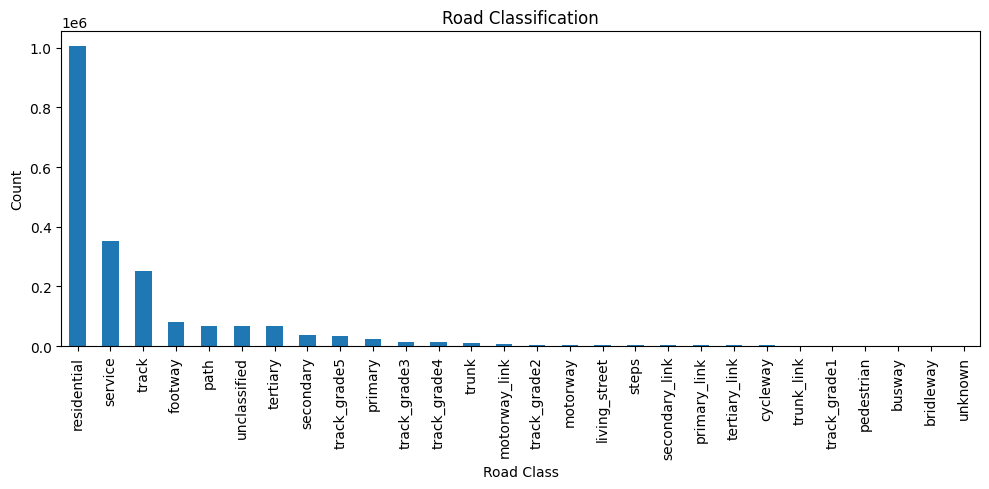

In [31]:
roads["fclass"].value_counts().plot.bar(figsize=(10,5))

plt.title("Road Classification")
plt.xlabel("Road Class")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

In [36]:
roads["ref"] = (roads["ref"].str.upper().str.strip().str.replace(r"\s*;\s*", ";", regex=True))

valid_routes = [f"N{i}" for i in range(1, 19)]

national = roads[roads["ref"].apply(lambda x: any(route in str(x).split(";") for route in valid_routes))]

national.head()

,osm_id,code,fclass,name,ref,oneway,maxspeed,layer,bridge,tunnel,geometry
142,4075691,5111,motorway,,N3,F,120,0,F,F,"LINESTRING (29.89906 -29.05166, 29.90025 -29.0..."
169,4085899,5111,motorway,Great West Way,N2,F,120,0,F,F,"LINESTRING (25.37848 -33.93979, 25.37787 -33.9..."
216,4218738,5111,motorway,Ben Schoeman Highway,N14,F,100,0,F,F,"LINESTRING (28.18275 -25.82408, 28.18263 -25.8..."
217,4218739,5111,motorway,Ben Schoeman Highway,N14,F,100,0,F,F,"LINESTRING (28.18385 -25.83905, 28.1837 -25.83..."
762,4225044,5111,motorway,,N14,F,120,0,F,F,"LINESTRING (28.07559 -25.89967, 28.07374 -25.9..."


In [37]:
len(national)

14049

In [39]:
sorted(national["ref"].unique())

['M5;N17',
 'N1',
 'N10',
 'N10;N12',
 'N10;N14',
 'N11',
 'N11;N17',
 'N11;R101',
 'N11;R101;R518',
 'N11;R518',
 'N11;R519',
 'N11;R543',
 'N11;R555',
 'N12',
 'N12;R558',
 'N12;R62',
 'N14',
 'N14;N10',
 'N14;R358',
 'N14;R359',
 'N14;R505',
 'N14;R563',
 'N17',
 'N17;M70',
 'N18',
 'N18;R377',
 'N1;N12',
 'N1;N4',
 'N1;N8',
 'N1;R389',
 'N1;R398',
 'N1;R43',
 'N1;R523',
 'N1;R578',
 'N2',
 'N2;M3',
 'N2;R317',
 'N2;R342',
 'N2;R346',
 'N2;R43',
 'N2;R543',
 'N2;R56',
 'N2;R67',
 'N3',
 'N3;N12',
 'N4',
 'N4;R36',
 'N4;R49',
 'N4;R539',
 'N4;R571',
 'N5',
 'N5;R70',
 'N5;R708',
 'N5;R70;R707',
 'N6',
 'N6;R102',
 'N6;R352',
 'N6;R61',
 'N6;R701',
 'N6;R717',
 'N7',
 'N7;R311',
 'N8',
 'N8;N12',
 'N8;R31',
 'N8;R370',
 'N8;R64',
 'N9',
 'N9;N10',
 'N9;N12',
 'N9;R339',
 'N9;R61',
 'N9;R61;R63',
 'N9;R62',
 'R24;N12',
 'R31;N12']

In [46]:
#Inspecting suspicious roads (Confirmed incorrect route overlap)
roads[roads["ref"] == "N2;R543"][["name", "ref", "geometry"]]

roads.loc[roads["ref"] == "N2;R543",["name", "ref", "fclass"]]

roads[roads["ref"] == "N2;R543"].shape

(1, 11)

In [48]:
national.crs

<Geographic 2D CRS: OGC:CRS84>
Name: WGS 84 (CRS84)
Axis Info [ellipsoidal]:
- Lon[east]: Geodetic longitude (degree)
- Lat[north]: Geodetic latitude (degree)
Area of Use:
- undefined
Datum: World Geodetic System 1984
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [49]:
national.geom_type.value_counts()

LineString    14049
Name: count, dtype: int64

In [50]:
national["ref"].value_counts().sort_index()

ref
M5;N17           1
N1            2362
N10            360
N10;N12          1
N10;N14          8
              ... 
N9;R61          59
N9;R61;R63      11
N9;R62          28
R24;N12          3
R31;N12          4
Name: count, Length: 76, dtype: int64

In [51]:
national["fclass"].value_counts()

fclass
trunk          10358
motorway        3644
secondary         30
primary            9
trunk_link         5
service            2
residential        1
Name: count, dtype: int64

In [53]:
national[national["fclass"] == "service"][["name", "ref", "fclass"]]

,name,ref,fclass
152639,,N4,service
152640,,N4,service


In [54]:
national[national["fclass"] == "residential"][["name", "ref", "fclass"]]

,name,ref,fclass
590287,Nelson Mandela Drive,N11,residential


In [55]:
national[national["fclass"] == "primary"][["name", "ref", "fclass"]]

,name,ref,fclass
2006,Nelson Mandela Boulevard,N2,primary
4047,Nelson Mandela Boulevard,N2,primary
112996,Monty Naicker Road,N3,primary
213587,Nelson Mandela Boulevard,N2,primary
225910,Nelson Mandela Boulevard,N2,primary
354649,Nelson Mandela Boulevard,N2,primary
385683,Nelson Mandela Boulevard,N2,primary
946690,Monty Naicker Road,N3,primary
1229727,Schoemanskloof,N4;R539,primary


In [57]:
#Note that all are related to the N17
national[national["fclass"] == "secondary"][["name", "ref", "fclass"]]

,name,ref,fclass
162261,,N17,secondary
162262,,N17,secondary
162263,,N17,secondary
334201,,N17,secondary
334206,,N17,secondary
345494,,N17,secondary
345495,,N17,secondary
345496,,N17,secondary
345497,,N17,secondary
345498,,N17,secondary
